In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
df_adv = pd.read_csv('facebook_ads_data (2.0).csv')

In [36]:
df_adv.sample(8)

,ad_date,campaign_name,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
189,2022-04-06,Hobbies,64.13,92767,606,82.11,0.11,0.69,0.006532,1.280368
761,2021-08-23,New items,42.16,12907,331,62.55,0.13,3.27,0.025645,1.483634
1016,2021-07-11,Crazy discounts,30.88,16177,77,33.67,0.40,1.91,0.004760,1.090350
1324,2021-05-05,Electronics,66.10,31588,211,93.46,0.31,2.09,0.006680,1.413918
1108,2021-06-26,New items,34.42,3855,220,31.50,0.16,8.93,0.057069,0.915166
575,2021-09-29,Crazy discounts,31.19,2975,57,24.53,0.55,10.48,0.019160,0.786470
1410,2021-01-21,Discounts,15.48,4956,202,25.10,0.08,3.12,0.040759,1.621447
511,2021-10-14,Crazy discounts,15.44,2705,34,13.84,0.45,5.71,0.012569,0.896373


In [37]:
print("shape: ", df_adv.shape, "\n")
print("columns: ", df_adv.columns, "\n")
print("index: ", df_adv.index, "\n")
print("dtypes: ", df_adv.dtypes, "\n")

shape:  (1494, 10) 

columns:  Index(['ad_date', 'campaign_name', 'total_spend', 'total_impressions',
       'total_clicks', 'total_value', 'cpc', 'cpm', 'ctr', 'romi'],
      dtype='object') 

index:  RangeIndex(start=0, stop=1494, step=1) 

dtypes:  ad_date               object
campaign_name         object
total_spend          float64
total_impressions      int64
total_clicks           int64
total_value          float64
cpc                  float64
cpm                  float64
ctr                  float64
romi                 float64
dtype: object 



In [38]:
df_adv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1494 entries, 0 to 1493
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ad_date            1494 non-null   object 
 1   campaign_name      1494 non-null   object 
 2   total_spend        1494 non-null   float64
 3   total_impressions  1494 non-null   int64  
 4   total_clicks       1494 non-null   int64  
 5   total_value        1494 non-null   float64
 6   cpc                1443 non-null   float64
 7   cpm                1462 non-null   float64
 8   ctr                1462 non-null   float64
 9   romi               1462 non-null   float64
dtypes: float64(6), int64(2), object(2)
memory usage: 116.8+ KB


In [39]:
df_adv.describe()

,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
count,1494.000000,1494.000000,1494.000000,1494.000000,1443.000000,1462.000000,1462.000000,1462.000000
mean,131.035964,34190.182062,318.840696,165.457450,0.814712,5.085677,0.011947,1.326322
std,214.968986,44433.507387,485.663099,274.764573,1.705224,8.107076,0.013192,0.343012
min,0.000000,0.000000,0.000000,0.000000,0.010000,0.050000,0.000000,0.751445
25%,18.047500,8377.000000,62.250000,24.350000,0.170000,1.500000,0.004462,1.067832
50%,48.515000,15983.000000,148.000000,65.460000,0.350000,2.775000,0.007845,1.299482
75%,161.790000,45849.750000,371.750000,196.595000,0.765000,5.275000,0.015005,1.527423
max,2035.490000,456481.000000,6199.000000,2562.600000,24.790000,114.150000,0.159223,2.486911


In [40]:
df_adv.ad_date = pd.to_datetime(df_adv.ad_date)

df_adv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1494 entries, 0 to 1493
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ad_date            1494 non-null   datetime64[ns]
 1   campaign_name      1494 non-null   object        
 2   total_spend        1494 non-null   float64       
 3   total_impressions  1494 non-null   int64         
 4   total_clicks       1494 non-null   int64         
 5   total_value        1494 non-null   float64       
 6   cpc                1443 non-null   float64       
 7   cpm                1462 non-null   float64       
 8   ctr                1462 non-null   float64       
 9   romi               1462 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(2), object(1)
memory usage: 116.8+ KB


In [41]:
daily_exp = (df_adv[df_adv['ad_date'].between('2021-01-01', '2021-12-31')].groupby('ad_date')['total_spend'].sum())

daily_exp

ad_date
2021-01-01      0.39
2021-01-02      7.74
2021-01-04     70.06
2021-01-05     81.15
2021-01-06    142.77
               ...  
2021-12-27    478.31
2021-12-28    359.83
2021-12-29    163.25
2021-12-30    285.67
2021-12-31    173.38
Name: total_spend, Length: 329, dtype: float64

In [42]:
daily_exp = daily_exp.reset_index()

daily_exp

,ad_date,total_spend
0,2021-01-01,0.39
1,2021-01-02,7.74
2,2021-01-04,70.06
3,2021-01-05,81.15
4,2021-01-06,142.77
...,...,...
324,2021-12-27,478.31
325,2021-12-28,359.83
326,2021-12-29,163.25
327,2021-12-30,285.67


In [43]:
daily_exp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 329 entries, 0 to 328
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   ad_date      329 non-null    datetime64[ns]
 1   total_spend  329 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.3 KB


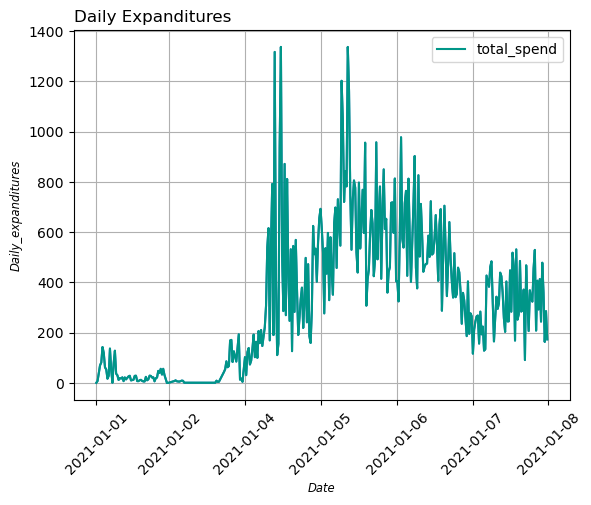

In [44]:
plt.plot('ad_date', 'total_spend', data = daily_exp, color='#009688')

plt.xlabel('Date', fontsize = 'small', fontstyle = 'italic')
plt.ylabel('Daily_expanditures', fontsize = 'small', fontstyle = 'italic')

plt.legend(loc = 'upper right')

plt.title('Daily Expanditures', fontsize = 'large', loc = 'left')

plt.style.use('default')
plt.grid()

plt.show()

In [45]:
daily_exp['ad_date'] = daily_exp['ad_date'].dt.date

*Графік з щоденним ROMI в 2021 році*

In [46]:
df_adv[df_adv['ad_date'].between('2021-01-01', '2021-12-31')].head(10)

,ad_date,campaign_name,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
274,2021-12-31,Lookalike,143.19,24699,194,138.86,0.74,5.80,0.007855,0.969760
275,2021-12-31,Trendy,8.82,25345,63,16.32,0.14,0.35,0.002486,1.850340
276,2021-12-31,Wholesale,21.37,6705,24,27.93,0.89,3.19,0.003579,1.306972
277,2021-12-30,Lookalike,227.56,44527,897,243.02,0.25,5.11,0.020145,1.067938
278,2021-12-30,Trendy,31.92,8833,58,63.67,0.55,3.61,0.006566,1.994674
279,2021-12-30,Wholesale,26.19,10811,29,23.57,0.90,2.42,0.002682,0.899962
280,2021-12-29,Lookalike,86.70,12408,293,72.28,0.30,6.99,0.023614,0.833679
281,2021-12-29,Trendy,15.75,7088,91,28.07,0.17,2.22,0.012839,1.782222
282,2021-12-29,Wholesale,60.80,12794,51,71.41,1.19,4.75,0.003986,1.174507
283,2021-12-28,Lookalike,283.48,69020,396,343.90,0.72,4.11,0.005737,1.213137


In [47]:
daily_values = df_adv[df_adv['ad_date'].between('2021-01-01', '2021-12-31')].groupby('ad_date', as_index = False).agg(
    expand = ('total_spend', 'sum'),
    revenue = ('total_value', 'sum')
)
daily_values

,ad_date,expand,revenue
0,2021-01-01,0.39,0.59
1,2021-01-02,7.74,6.90
2,2021-01-04,70.06,68.47
3,2021-01-05,81.15,61.68
4,2021-01-06,142.77,145.97
...,...,...,...
324,2021-12-27,478.31,686.47
325,2021-12-28,359.83,450.47
326,2021-12-29,163.25,171.76
327,2021-12-30,285.67,330.26


In [48]:
daily_values['romi_day'] = daily_values.revenue/daily_values.expand
daily_values

,ad_date,expand,revenue,romi_day
0,2021-01-01,0.39,0.59,1.512821
1,2021-01-02,7.74,6.90,0.891473
2,2021-01-04,70.06,68.47,0.977305
3,2021-01-05,81.15,61.68,0.760074
4,2021-01-06,142.77,145.97,1.022414
...,...,...,...,...
324,2021-12-27,478.31,686.47,1.435199
325,2021-12-28,359.83,450.47,1.251897
326,2021-12-29,163.25,171.76,1.052129
327,2021-12-30,285.67,330.26,1.156089


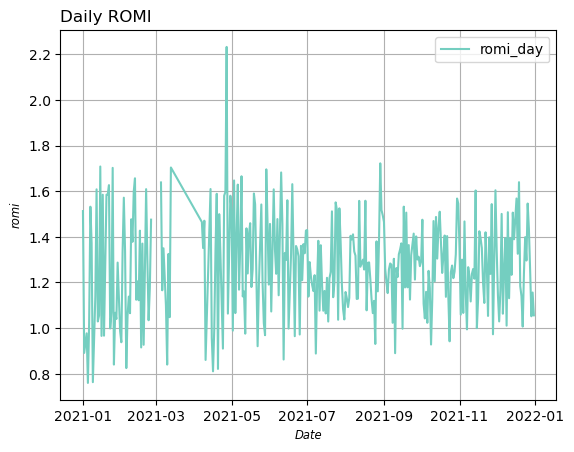

In [49]:
plt.plot('ad_date', 'romi_day', data = daily_values, color='#74cec0')

plt.xlabel('Date', fontsize = 'small', fontstyle = 'italic')
plt.ylabel('romi', fontsize = 'small', fontstyle = 'italic')

plt.legend(loc = 'upper right')

plt.title('Daily ROMI', fontsize = 'large', loc = 'left')

plt.grid()

plt.show()

*Застосуй метод rolling() щоб відобразити рухоме середнє витрат та ROMI*

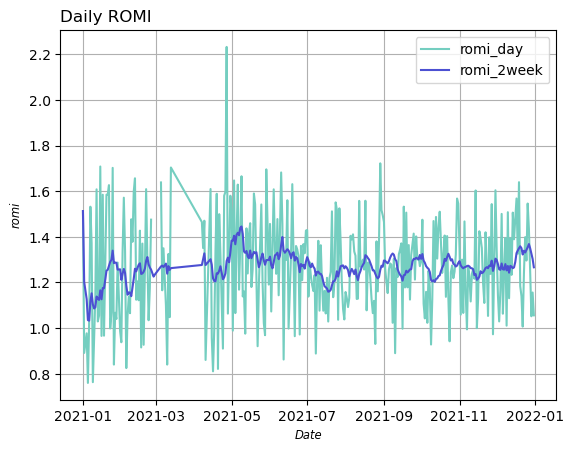

In [50]:
daily_values['romi_2week'] = daily_values['romi_day'].rolling(window = 14, min_periods = 1).mean()

plt.plot('ad_date', 'romi_day', data = daily_values, color='#74cec0')

plt.plot('ad_date', 'romi_2week', data = daily_values, color='#4c50d2')

plt.xlabel('Date', fontsize = 'small', fontstyle = 'italic')
plt.ylabel('romi', fontsize = 'small', fontstyle = 'italic')

plt.legend(loc = 'upper right')

plt.title('Daily ROMI', fontsize = 'large', loc = 'left')

plt.grid()

plt.show()

*Графік загальної суми витрат на рекламу в кожній з кампаній.*
*Загальний ROMI в кожній з кампаній*

In [51]:
display(df_adv.sample(8))

,ad_date,campaign_name,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
1192,2021-06-11,New items,70.52,24812,134,106.23,0.53,2.84,0.005401,1.506381
1137,2021-06-21,Electronics,21.73,3232,19,23.41,1.14,6.72,0.005879,1.077312
443,2021-11-07,Wholesale,43.75,9332,112,52.68,0.39,4.69,0.012002,1.204114
1185,2021-06-12,Lookalike,289.53,83600,484,224.52,0.60,3.46,0.005789,0.775464
452,2021-11-02,Lookalike,144.27,60815,677,166.80,0.21,2.37,0.011132,1.156166
1148,2021-06-19,Electronics,12.33,6808,29,13.29,0.43,1.81,0.004260,1.077859
553,2021-10-04,Electronics,188.13,7884,278,199.18,0.68,23.86,0.035261,1.058736
1351,2021-04-14,Electronics,43.33,65315,619,69.73,0.07,0.66,0.009477,1.609278


In [52]:
val_ttl_campaign = df_adv.groupby('campaign_name', as_index = False).agg(
    expand = ('total_spend', 'sum'),
    revenue = ('total_value', 'sum')
)

In [53]:
val_ttl_campaign['romi_camp'] = val_ttl_campaign.revenue/val_ttl_campaign.expand
display(val_ttl_campaign)

,campaign_name,expand,revenue,romi_camp
0,Brand,539.92,670.15,1.241202
1,Crazy discounts,2175.29,2583.59,1.187699
2,Discounts,2856.39,3516.27,1.231019
3,Electronics,23920.42,29169.38,1.219434
4,Expansion,67212.82,83288.66,1.239178
5,Hobbies,11326.97,13974.63,1.233748
6,Lookalike,63631.09,80234.70,1.260935
7,New items,2936.97,3742.05,1.274119
8,Promos,4993.84,8793.77,1.760923
9,Trendy,1992.31,3798.90,1.906782


C:\Users\konst\AppData\Local\Temp\ipykernel_4876\4002846313.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\konst\AppData\Local\Temp\ipykernel_4876\4002846313.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


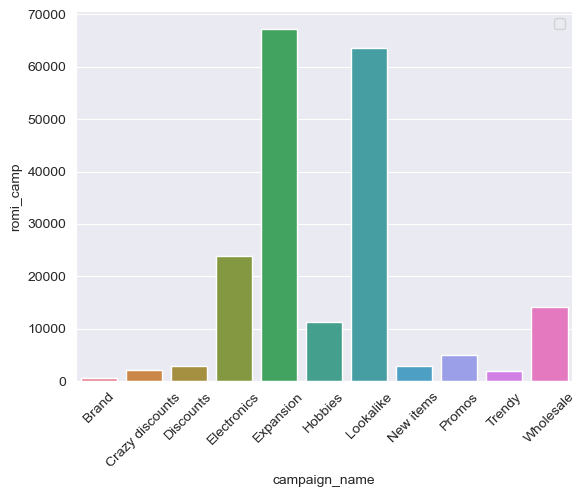

In [57]:
sns.set_style("darkgrid")

ax = sns.barplot(
    data=val_ttl_campaign,
    x='campaign_name',
    y='expand',
    hue='campaign_name'
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

if val_ttl_campaign['campaign_name'].nunique() > 1:
    ax.legend(loc='upper right')
else:
    ax.legend_.remove()

plt.show()

C:\Users\konst\AppData\Local\Temp\ipykernel_4876\237524083.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\konst\AppData\Local\Temp\ipykernel_4876\237524083.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


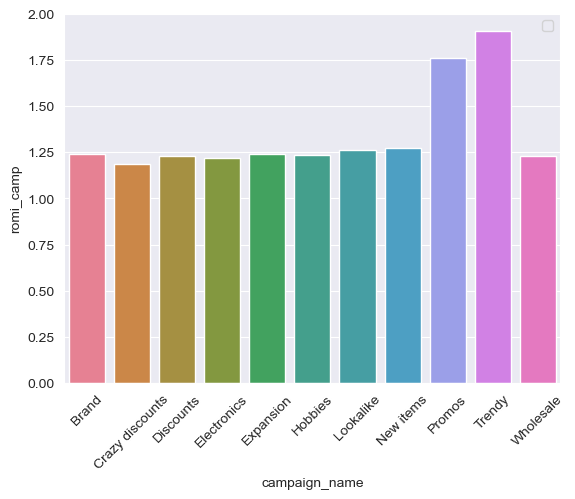

In [58]:
sns.set_style("darkgrid")

ax = sns.barplot(
    data=val_ttl_campaign,
    x='campaign_name',
    y='romi_camp',
    hue='campaign_name'
)


ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


if val_ttl_campaign['campaign_name'].nunique() > 1:
    ax.legend(loc='upper right')
else:
    ax.legend_.remove()

plt.show()

In [59]:
values_day = df_adv.groupby(['campaign_name', 'ad_date'], as_index = False).agg(
    expand = ('total_spend', 'sum'),
    revenue = ('total_value', 'sum')
)
values_day

,campaign_name,ad_date,expand,revenue
0,Brand,2020-12-25,10.99,16.91
1,Brand,2020-12-26,17.64,25.55
2,Brand,2020-12-27,19.49,24.69
3,Brand,2020-12-28,27.84,36.71
4,Brand,2020-12-29,13.40,11.15
...,...,...,...,...
1489,Wholesale,2022-01-01,0.00,0.00
1490,Wholesale,2022-01-02,0.00,0.00
1491,Wholesale,2022-01-03,0.00,0.00
1492,Wholesale,2022-01-04,0.00,0.00


In [60]:
values_day['roas'] = values_day.revenue/values_day.expand
values_day

,campaign_name,ad_date,expand,revenue,roas
0,Brand,2020-12-25,10.99,16.91,1.538672
1,Brand,2020-12-26,17.64,25.55,1.448413
2,Brand,2020-12-27,19.49,24.69,1.266803
3,Brand,2020-12-28,27.84,36.71,1.318606
4,Brand,2020-12-29,13.40,11.15,0.832090
...,...,...,...,...,...
1489,Wholesale,2022-01-01,0.00,0.00,NaN
1490,Wholesale,2022-01-02,0.00,0.00,NaN
1491,Wholesale,2022-01-03,0.00,0.00,NaN
1492,Wholesale,2022-01-04,0.00,0.00,NaN


In [61]:
values_day = values_day.dropna()

values_day

,campaign_name,ad_date,expand,revenue,roas
0,Brand,2020-12-25,10.99,16.91,1.538672
1,Brand,2020-12-26,17.64,25.55,1.448413
2,Brand,2020-12-27,19.49,24.69,1.266803
3,Brand,2020-12-28,27.84,36.71,1.318606
4,Brand,2020-12-29,13.40,11.15,0.832090
...,...,...,...,...,...
1484,Wholesale,2021-12-27,28.54,29.72,1.041345
1485,Wholesale,2021-12-28,49.19,58.14,1.181948
1486,Wholesale,2021-12-29,60.80,71.41,1.174507
1487,Wholesale,2021-12-30,26.19,23.57,0.899962


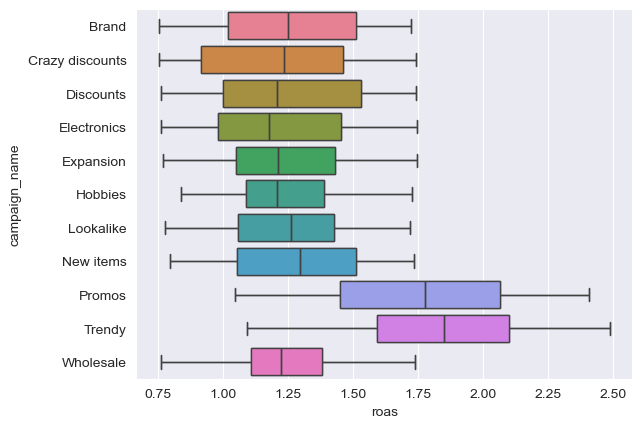

In [63]:
sns.set_style("darkgrid")

ax = sns.boxplot(
    data=values_day,
    x='roas',
    y='campaign_name',
    hue='campaign_name'
)

plt.show()

*Побудуй гістограму з розподілом значень ROMI в таблиці facebook_ads_data.csv*

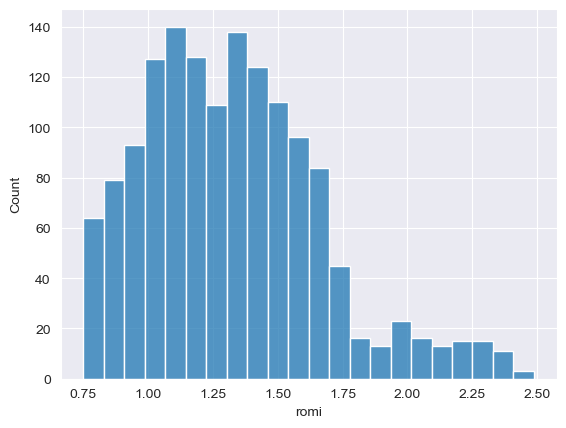

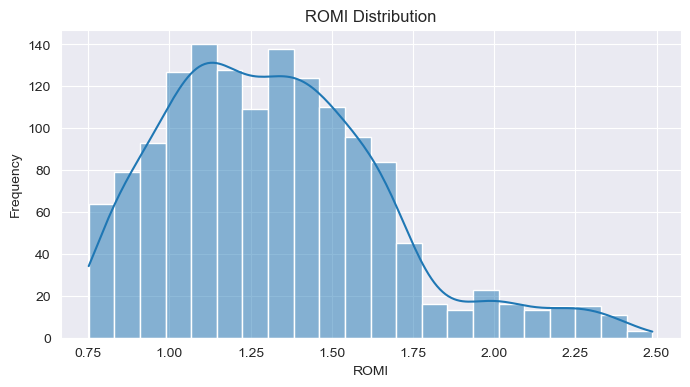

In [65]:
sns.set_style("darkgrid")

plt.figure(figsize=(8, 4))
sns.histplot(data=df_adv, x='romi', kde=True)

plt.xlabel('ROMI')
plt.ylabel('Frequency')
plt.title('ROMI Distribution')

plt.show()

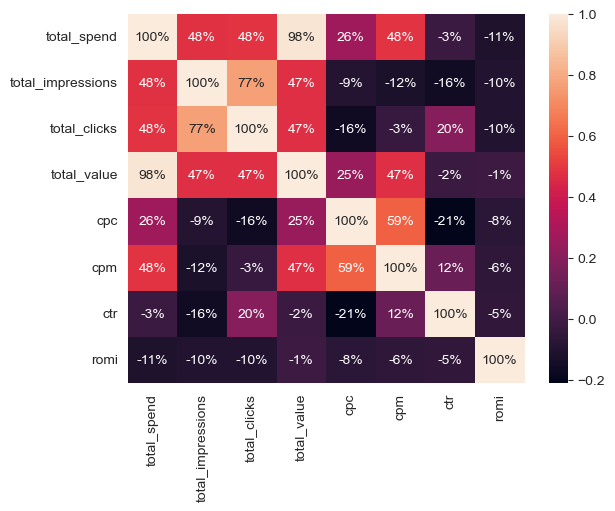

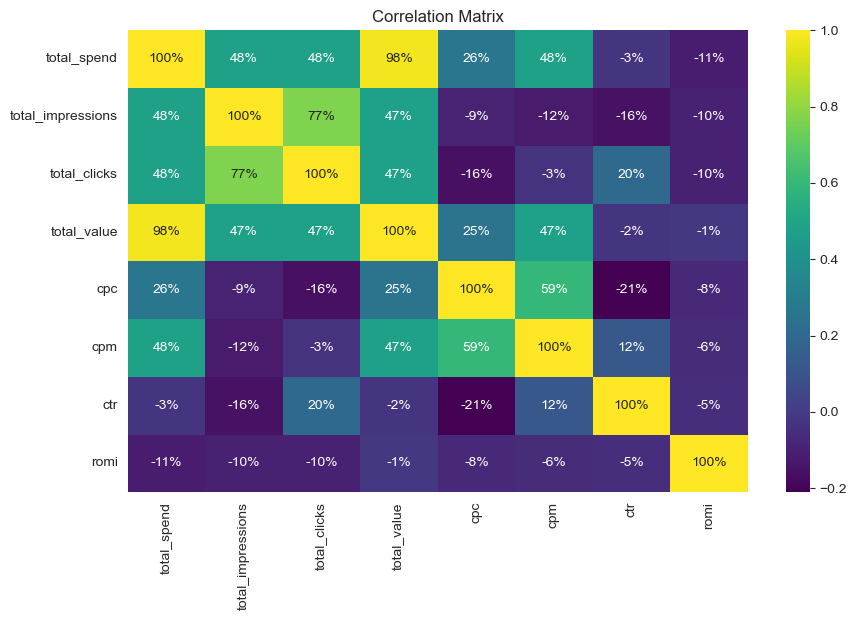

In [67]:
sns.set_style("darkgrid")

plt.figure(figsize=(10, 6))
sns.heatmap(df_adv.corr(numeric_only=True), annot=True, fmt='.0%', cmap='viridis')

plt.title('Correlation Matrix')
plt.show()

*Найвищу кореляцю мають: total_spend^total_value, total_clicks^total_impressions, cpm^cpc, total_spend^cpm, total_spend^total_impressions*

*Найнижчу кореляцію мають: total_spend^ctr, total_clicks^cpm, total_value^ctr, total_value^romi, ctr^romi*

*total_value корелює з total_spend, total_impressions, total_clicks, cpm*

кореляція total_spend" та "total_value"*

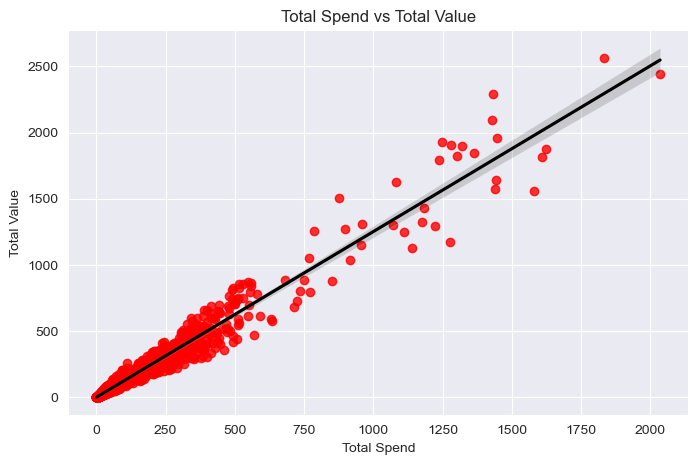

In [68]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df_adv,
    x='total_spend',
    y='total_value',
    scatter_kws={'color': 'red'},
    line_kws={'color': 'black'}
)

plt.title('Total Spend vs Total Value')
plt.xlabel('Total Spend')
plt.ylabel('Total Value')

plt.show()